# Customer Lifetime Value Prediction

## Objective

This notebook builds machine learning models to predict the future monetary value of customers.

Predicting CLV enables businesses to:

- Optimize marketing budgets
- Personalize customer engagement
- Identify high-value customers early
- Improve customer retention

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [2]:
ml_dataset = pd.read_csv(
    r"C:\Users\swastik\Desktop\customer_intelligence_platform\datasets\Olist\customer_ml_dataset.csv",
    index_col=0
)

ml_dataset.head()

,Recency,Frequency,Monetary,AvgOrderValue,AvgReview,AvgDelivery,AvgDelay,AvgPayment,MaxPayment,TotalPayment,FavoriteMonth,FavoriteDay
customer_unique_id,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,-0.833126,-0.161046,-0.111606,-0.076092,0.673055,-0.640644,0.683347,-0.076092,-0.086539,-0.111606,-0.311420,0.132859
0000b849f77a49e4a4ce2b2a4ca5be3f,-0.813538,-0.161046,-0.289243,-0.600908,-0.082183,-0.957997,0.683347,-0.600908,-0.604865,-0.289243,-0.311420,-1.392812
0000f46a3911fa3c0805444483337064,1.948413,-0.161046,-0.197830,-0.330837,-0.837420,1.369254,0.982422,-0.330837,-0.338133,-0.197830,-0.931143,0.641417
0000f6ccb0745a6a4b88665a16c9f078,0.538055,-0.161046,-0.263800,-0.525739,-0.082183,0.840333,-0.014495,-0.525739,-0.530625,-0.263800,1.237887,0.132859
0004aac84e0df4da2b147fca70cf8255,0.322584,-0.161046,-0.026450,0.175495,0.673055,0.099844,0.384272,0.175495,0.161938,-0.026450,1.547749,-0.884255


In [3]:
X = ml_dataset.drop(columns=[
    "Monetary",
    "TotalPayment",
    "AvgPayment",
    "AvgOrderValue"
])

y = ml_dataset["Monetary"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
baseline_prediction = np.repeat(
    y_train.mean(),
    len(y_test)
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

print(f"Baseline MAE : {baseline_mae:.2f}")

Baseline MAE : 0.28


In [6]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [7]:
print("Random Forest")

print(
    "MAE :",
    mean_absolute_error(y_test, rf_pred)
)

print(
    "RMSE :",
    np.sqrt(
        mean_squared_error(
            y_test,
            rf_pred
        )
    )
)

print(
    "R² :",
    r2_score(
        y_test,
        rf_pred
    )
)

Random Forest
MAE : 0.12242327809068007
RMSE : 1.1603826595877627
R² : 0.378437763367823


In [8]:
xgb = XGBRegressor(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

In [9]:
print("XGBoost")

print(
    "MAE :",
    mean_absolute_error(y_test, xgb_pred)
)

print(
    "RMSE :",
    np.sqrt(
        mean_squared_error(
            y_test,
            xgb_pred
        )
    )
)

print(
    "R² :",
    r2_score(
        y_test,
        xgb_pred
    )
)

XGBoost
MAE : 0.12840500777079772
RMSE : 1.3629497471241192
R² : 0.14248476004962995


In [10]:
comparison = pd.DataFrame({

    "Model":[

        "Baseline",

        "Random Forest",

        "XGBoost"

    ],

    "MAE":[

        baseline_mae,

        mean_absolute_error(
            y_test,
            rf_pred
        ),

        mean_absolute_error(
            y_test,
            xgb_pred
        )

    ]

})

comparison

,Model,MAE
0,Baseline,0.283825
1,Random Forest,0.122423
2,XGBoost,0.128405


In [11]:
fig = px.bar(

    comparison,

    x="Model",

    y="MAE",

    color="Model",

    title="Model Comparison"

)

fig.show()

In [12]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
5,MaxPayment,0.622193
0,Recency,0.082395
4,AvgDelay,0.072500
3,AvgDelivery,0.057561
6,FavoriteMonth,0.052332
1,Frequency,0.042908
2,AvgReview,0.041504
7,FavoriteDay,0.028608


In [13]:
fig = px.bar(

    importance.head(10),

    x="Importance",

    y="Feature",

    orientation="h",

    title="Top Features Driving CLV",

    template="plotly_white"

)

fig.show()

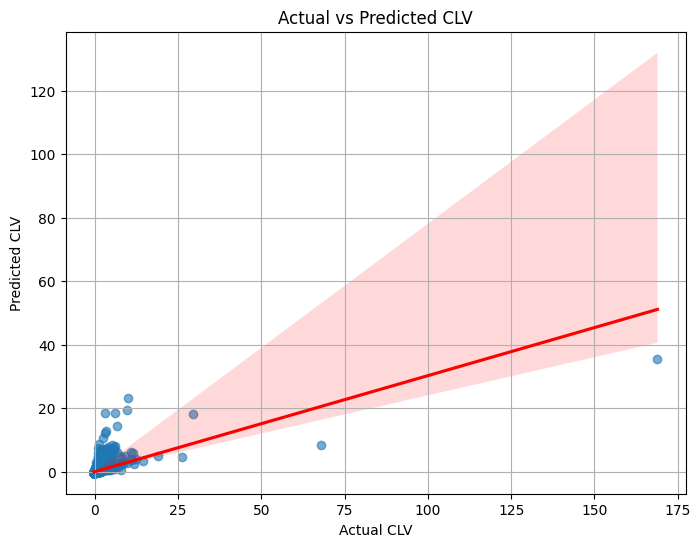

In [14]:


results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_pred
})

plt.figure(figsize=(8,6))

sns.regplot(
    data=results,
    x="Actual",
    y="Predicted",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Actual vs Predicted CLV")
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.grid(True)
plt.show()